In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

import torch
import math
from sklearn.cluster import DBSCAN
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, RobertaModel, RobertaTokenizer

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
leetcode_questions_df = pd.read_csv('/content/drive/MyDrive/thesis/leetcode/part4 feature-engineering/leetcode_questions_df.csv')

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61834 entries, 0 to 61833
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            61834 non-null  object 
 1   country                             61834 non-null  object 
 2   contest_url                         61834 non-null  object 
 3   num_of_contest                      61834 non-null  int64  
 4   is_weekly                           61834 non-null  bool   
 5   rank                                61834 non-null  int64  
 6   score                               61834 non-null  int64  
 7   question_number                     61834 non-null  int64  
 8   question_language                   61834 non-null  object 
 9   question_code                       61834 non-null  object 
 10  number_of_lines                     61834 non-null  int64  
 11  names_set                           61834

In [4]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_language'] == 'java']
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_number'] > 2]
leetcode_questions_df = leetcode_questions_df.drop_duplicates(subset=['question_code'])
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['country'].isin(leetcode_questions_df['country'].value_counts().head(2).index)]

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2101 entries, 524 to 61818
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            2101 non-null   object 
 1   country                             2101 non-null   object 
 2   contest_url                         2101 non-null   object 
 3   num_of_contest                      2101 non-null   int64  
 4   is_weekly                           2101 non-null   bool   
 5   rank                                2101 non-null   int64  
 6   score                               2101 non-null   int64  
 7   question_number                     2101 non-null   int64  
 8   question_language                   2101 non-null   object 
 9   question_code                       2101 non-null   object 
 10  number_of_lines                     2101 non-null   int64  
 11  names_set                           2101 non-

In [5]:
model_name = "neulab/codebert-java"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = RobertaModel.from_pretrained(model_name)

code_snippets = leetcode_questions_df.question_code.tolist()

# Step 1: Encode the code snippets using CodeBERT
def get_embeddings(code_snippet):
    inputs = tokenizer(code_snippet, return_tensors='pt', truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    # Use the last hidden state of the [CLS] token as the embedding
    return outputs.last_hidden_state[:, 0, :].numpy()

# Get embeddings for all code snippets
embeddings = np.vstack([get_embeddings(snippet) for snippet in code_snippets])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.54k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/696 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at neulab/codebert-java and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [6]:
min_samples = 10 ** (math.floor(math.log10(len(code_snippets))) - 1)

min_samples

100

In [7]:
# Step 2: Apply DBSCAN for clustering and outlier detection
dbscan = DBSCAN(eps=0.1, min_samples=min_samples, metric='cosine', n_jobs=-1)
db_labels = dbscan.fit_predict(embeddings)

# Step 3: Identify and handle outliers
outliers = np.where(db_labels == -1)[0]

# Output some statistics
print(f'Removed {len(outliers)} outliers.')
print(f'Retained {len(db_labels) - len(outliers)} code snippets.')

Removed 53 outliers.
Retained 2048 code snippets.


In [8]:
# Remove outliers from the DataFrame
leetcode_questions_df.reset_index(drop=True, inplace=True)
leetcode_questions_df = leetcode_questions_df[~leetcode_questions_df.index.isin(outliers)]

leetcode_questions_df.country.value_counts()

,count
country,
India,1344
United States,704


In [9]:
leetcode_questions_df.drop(['num_of_contest','is_weekly','rank','score','global_rank_percentile','num_contests_participated','question_number'],axis=1, inplace=True)

<ipython-input-9-968ae4088e84>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leetcode_questions_df.drop(['num_of_contest','is_weekly','rank','score','global_rank_percentile','num_contests_participated','question_number'],axis=1, inplace=True)


In [10]:
X=leetcode_questions_df.drop('country',axis=1)
Y=leetcode_questions_df.country

In [11]:
X_nontext=X.select_dtypes(exclude=['object'])
X_nontext.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2048 entries, 0 to 2100
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   number_of_lines                     2048 non-null   int64  
 1   token_count                         2048 non-null   int64  
 2   variables_count                     2048 non-null   int64  
 3   function_count                      2048 non-null   int64  
 4   loop_count                          2048 non-null   int64  
 5   condition_count                     2048 non-null   int64  
 6   single_line_comment_density         2048 non-null   float64
 7   multiline_comment_density           2048 non-null   float64
 8   function_density                    2048 non-null   float64
 9   loop_density                        2048 non-null   float64
 10  condition_density                   2048 non-null   float64
 11  comment_tokens_density              2048 non-nul

In [12]:
X_train_nontext, X_test_nontext, y_train, y_test = train_test_split(X_nontext, Y, test_size=0.25, random_state=0,stratify=Y)

In [13]:
def print_test_confusion_matrix():
  disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred), display_labels=grid_search.classes_)

  fig, ax = plt.subplots(figsize=(15,10))
  disp.plot(ax=ax)

  plt.show()

# Decision Tree - All

In [14]:
baseline_model = Pipeline([('scaler',StandardScaler()),
                           ('classifier',DecisionTreeClassifier(random_state = 42))])

In [15]:
scores = cross_val_score(baseline_model, X_train_nontext, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.610681500909514


In [16]:
param_grid = {'classifier__max_depth' : [7, 9, 11, None],
              'classifier__min_samples_split' : [4, 8, 12],
              'classifier__criterion' :['gini', 'entropy']
             }

grid_search = GridSearchCV(estimator=baseline_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1_macro')

grid_search.fit(X_train_nontext, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_dt = grid_search.best_estimator_
y_pred = best_dt.predict(X_test_nontext)
print("Test set F1 score: ", f1_score(y_test, y_pred, average='macro'))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters found:  {'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_split': 12}
Best F1 score found:  0.6053288304600473
Test set F1 score:  0.5757203642718213


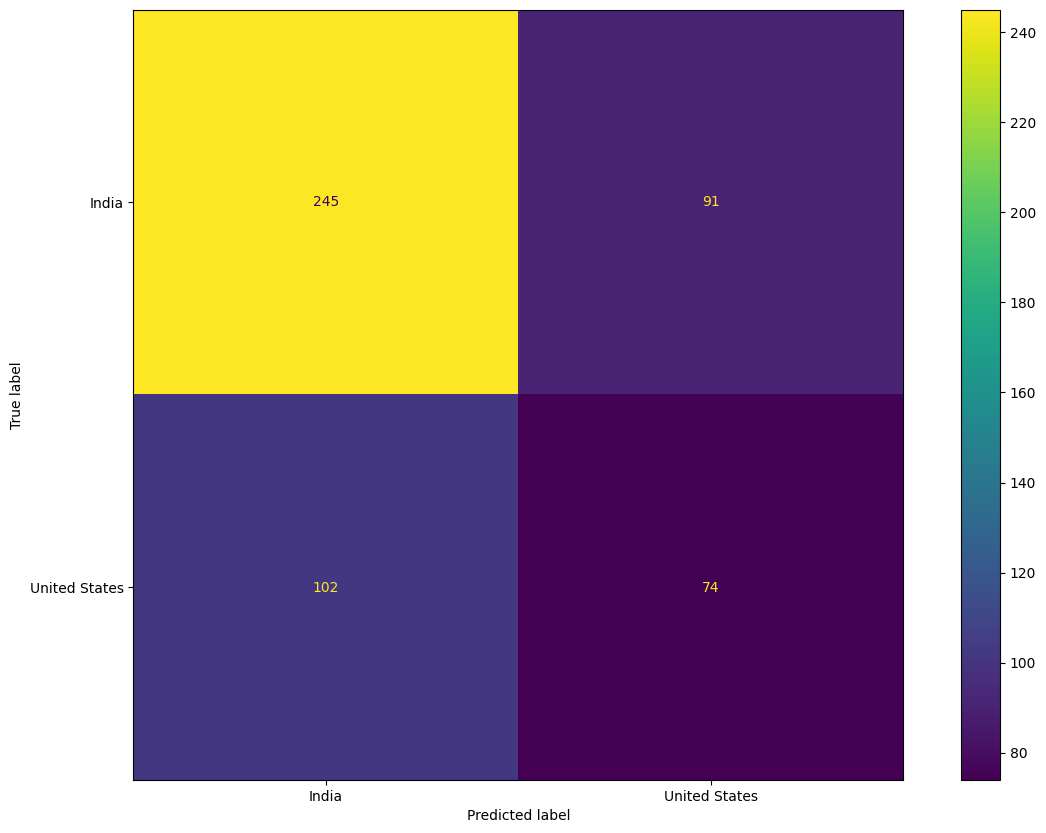

In [17]:
print_test_confusion_matrix()

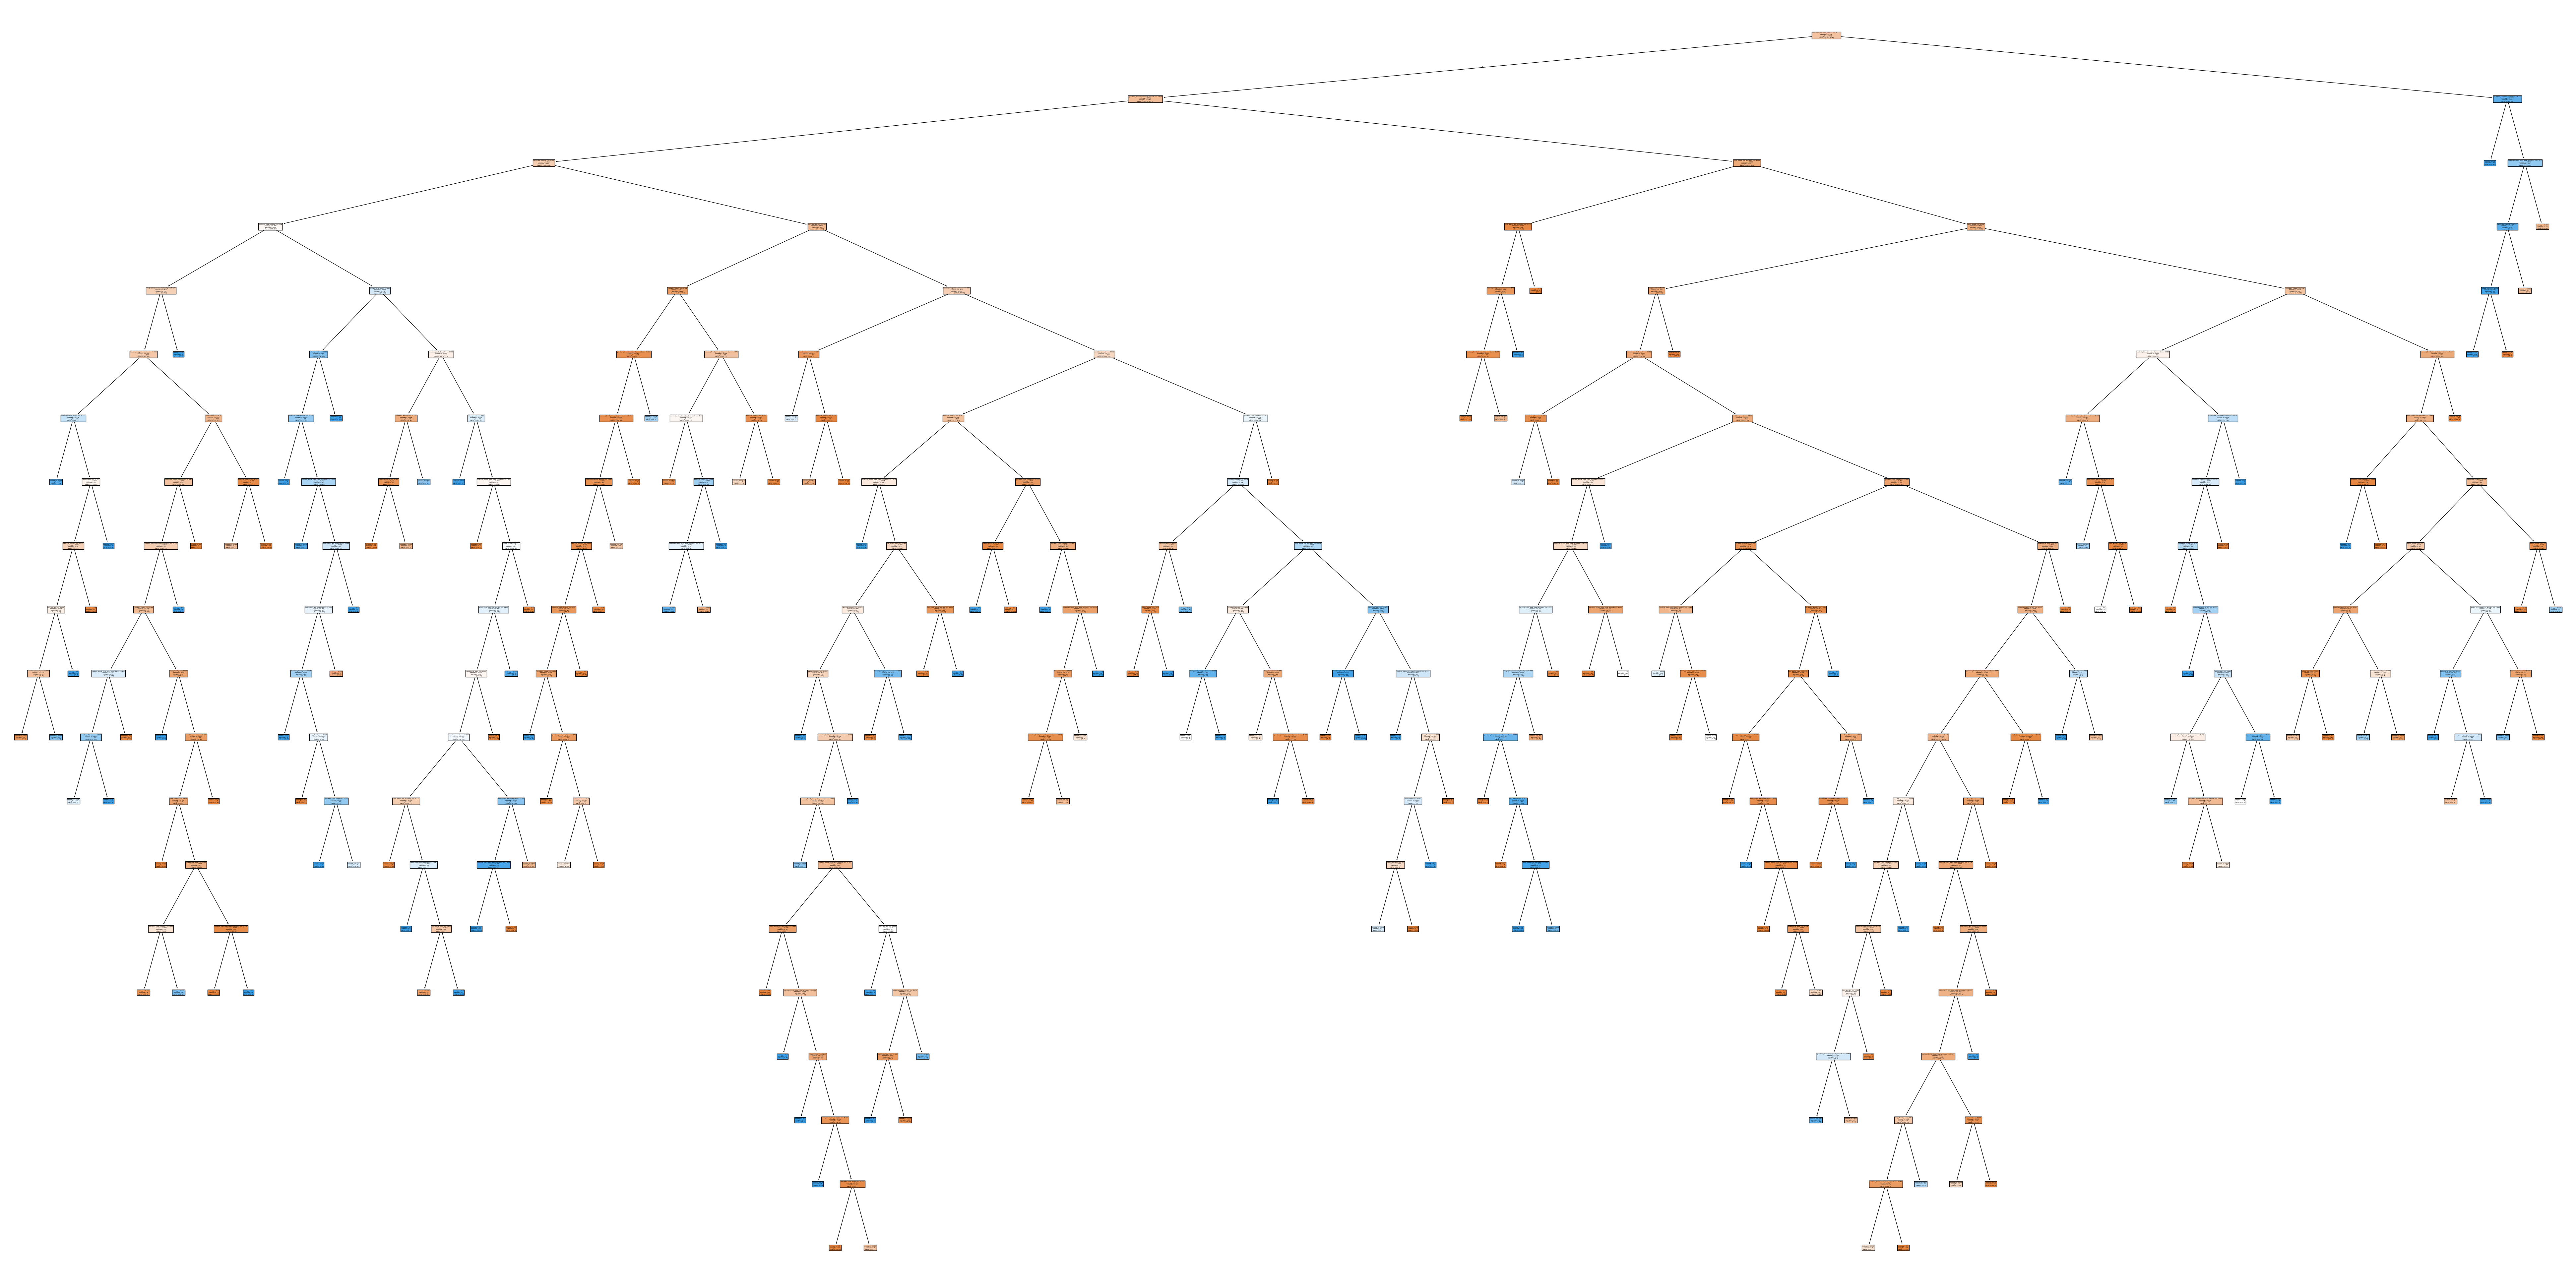

In [18]:
_, ax = plt.subplots(figsize=(100,50)) # Resize figure
plot_tree(best_dt['classifier'], filled=True, ax=ax, feature_names = X_train_nontext.columns.to_numpy())
plt.show()

# Random Forest

In [19]:
baseline_model = Pipeline([('scaler',StandardScaler()),
                           ('classifier',RandomForestClassifier())])

In [20]:
scores = cross_val_score(baseline_model, X_train_nontext, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.6901053344050087


In [21]:
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [10, 20, 30],
    'classifier__bootstrap': [True, False]
}

grid_search = GridSearchCV(estimator=baseline_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1_macro')

grid_search.fit(X_train_nontext, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test_nontext)
print("Test set F1 score: ", f1_score(y_test, y_pred, average='macro'))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters found:  {'classifier__bootstrap': True, 'classifier__max_depth': 20, 'classifier__n_estimators': 100}
Best F1 score found:  0.6181284375208855
Test set F1 score:  0.6076628352490422


In [22]:
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

        India       0.72      0.89      0.79       336
United States       0.61      0.32      0.42       176

     accuracy                           0.70       512
    macro avg       0.66      0.61      0.61       512
 weighted avg       0.68      0.70      0.67       512



# KNN

In [23]:
baseline_model = Pipeline([('scaler',StandardScaler()),
                           ('classifier',KNeighborsClassifier())])

In [24]:
scores = cross_val_score(baseline_model, X_train_nontext, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.645831041922247


In [25]:
param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(estimator=baseline_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1')

grid_search.fit(X_train_nontext, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test_nontext)
print("Test set F1 score: ", f1_score(y_test, y_pred, average='macro'))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters found:  {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 3, 'classifier__weights': 'uniform'}
Best F1 score found:  nan
Test set F1 score:  0.6202363292240012


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


# Support Vector Classifier

In [26]:
baseline_model = Pipeline([('scaler',StandardScaler()),
                           ('classifier',SVC(probability=True))])

In [27]:
scores = cross_val_score(baseline_model, X_train_nontext, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.6868458902660857


In [28]:
param_grid = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ['scale', 'auto'],
    'classifier__kernel': ['linear', 'poly', 'rbf', 'sigmoid']
}

grid_search = GridSearchCV(estimator=baseline_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1_macro')

grid_search.fit(X_train_nontext, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_svc = grid_search.best_estimator_
y_pred = best_svc.predict(X_test_nontext)
print("Test set F1 score: ", f1_score(y_test, y_pred, average='macro'))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters found:  {'classifier__C': 10, 'classifier__gamma': 'auto', 'classifier__kernel': 'sigmoid'}
Best F1 score found:  0.5506569746987829
Test set F1 score:  0.5232774674115456


In [29]:
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

        India       0.67      0.66      0.67       336
United States       0.37      0.39      0.38       176

     accuracy                           0.57       512
    macro avg       0.52      0.52      0.52       512
 weighted avg       0.57      0.57      0.57       512

